In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(words[:8])

32033
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {v:k for k, v in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
import random
random.seed(42)
random.shuffle(words)

In [5]:
# build the dataset
block_size = 8

def build_dataset(words):
    X, Y = [], []
        
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [6]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

class Embedding:
  def __init__(self, num_embeddings, embedding_dim):
    self.weights = torch.randn((num_embeddings, embedding_dim))
  
  def __call__(self, IX):
    self.out = self.weights[IX]
    return self.out

  def parameters(self):
    return [self.weights]


class FlattenConsecutive:
  
  def __init__(self, n):
    self.n = n
  
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out
  
  def parameters(self):
    return []

class Sequential:
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [7]:
torch.manual_seed(42);

In [24]:
n_embd = 24
n_hidden = 128 #200 # changing this to 68 so as to keep the number of parameters approx same as before so as to compare the performance of the architecture
# now since we have introduced Embedding class and a Flatten class, we can add these in the layers list and remove C and emb variables that we have used
# model = Sequential([
#     Embedding(vocab_size, n_embd),
#     FlattenConsecutive(block_size),
#     Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#     Linear(n_hidden, vocab_size)
# ])
# this is exactly the same model if we n = block_size
model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

76579


in the first step itself of the model, we are squashing all the characters (8 in our case) together in a vector and giving as an input to further layers.\
we are losing so much of meaningful information at just this step.\
that is why we will take a wavenet type approach in which we take first two characters, squash them and send it forward along with all the pairs.\
we are taking this heirarchical type of approach here.

In [9]:
ix = torch.randint(0, Xtr.shape[0], (4, ))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)

In [10]:
for layer in model.layers:
    print(layer.__class__.__name__, ":", tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


All the shapes above are coming out to be as we imagined them to be. We still have to check if BatchNorm1d is behaving fine with 3 dimensions.

In [11]:
model.layers[0].out.shape # embedding layer

torch.Size([4, 8, 10])

In [12]:
model.layers[1].out.shape # Flatten layer

torch.Size([4, 4, 20])

In [13]:
model.layers[2].out.shape # linear layer

torch.Size([4, 4, 68])

In [14]:
(torch.randn((4, 4, 20)) @ torch.randn((20, 200)) + torch.randn(200)).shape  # this is the transformation that is taking place. We can add a dimension in the matrices for matrix multiplication
# matrix multiplication will only take place at the outermost layer. 

torch.Size([4, 4, 200])

From the output blocks above, we can see that before flatten layer, we are taking 8 chars for each input. Now we want is to take 2 characters at a time.\
We can add a dimension so as to deal with that.\
Basically, in the first layer, the output shape is (4, 8, 10). We can make it (4, 4, 2, 10). And then pass it on to flatten layer. We expect the shape (4, 4, 20) after that.

In [15]:
temp = torch.arange(10)
temp[::2], temp[1::2]  # by this we can get even indices and odd indices

(tensor([0, 2, 4, 6, 8]), tensor([1, 3, 5, 7, 9]))

In [16]:
# so what we want is in the flatten layer, we want to concatenate odd indices with even indices.
# we can do it like this
# suppose we have a tensor called e
e = torch.randn((4, 8, 10)) # we want this to be (4, 4, 20) where consecutive 10 dimension vectors get concatenated
# we can do it like 
explicit = torch.cat((e[:, ::2, :], e[:, 1::2, ::]), dim=2)
explicit.shape

torch.Size([4, 4, 20])

In [17]:
# there is a more efficient way to do this just by using view function
(e.view(4, 4, 20) == explicit).all() # so basically this gives us exactly what we want

tensor(True)

In [25]:
# optimization

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # minibatch constuct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update simple SGD
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    # break


      0/ 200000: 3.2955
  10000/ 200000: 2.5718
  20000/ 200000: 2.1536
  30000/ 200000: 2.0747
  40000/ 200000: 2.4949
  50000/ 200000: 1.8815
  60000/ 200000: 1.7973
  70000/ 200000: 1.7673
  80000/ 200000: 1.7797
  90000/ 200000: 1.9748
 100000/ 200000: 1.9738
 110000/ 200000: 2.0479
 120000/ 200000: 2.2329
 130000/ 200000: 1.9100
 140000/ 200000: 1.3345
 150000/ 200000: 1.8465
 160000/ 200000: 2.0641
 170000/ 200000: 1.7641
 180000/ 200000: 1.8310
 190000/ 200000: 1.9827


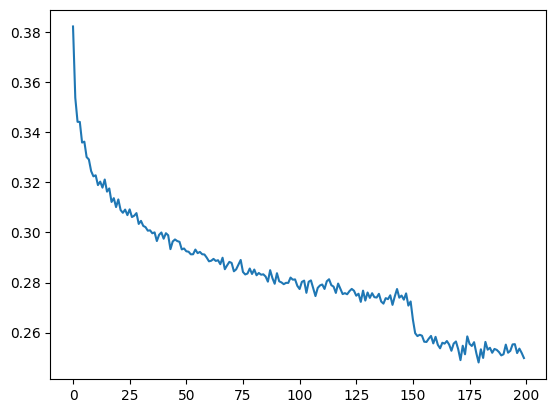

In [26]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [27]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [28]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


split_loss('train')
split_loss('val')

train 1.764130711555481
val 1.9889545440673828


Performance log\
when context length is 3: train 2.0394399166107178 val 2.10412859916687\
When context length is 8 (no. of parameters: 22097): train 1.9168884754180908 val 2.0341293811798096\
Performance increased when we increased context length from 3 -> 8\
We would consider this the baseline performance as we improve the performance with the heirarchical approach\
Heirarchical approach (no. of parameters: 22397): train 1.9160150289535522 val 2.022462844848633\
Heirarchical approach (no. of parameters: 76579): train 1.764130711555481 val 1.9889545440673828

In [29]:
# sample from the model


for _ in range(25):
    out = []
    context = [0] * block_size
    while True:
        x = torch.tensor([context])
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(itos[ix])
        if ix == 0:
            break
    
    print(''.join(out))

leon.
ahsyn.
malakee.
afhira.
emure.
anissandra.
tera.
talmadi.
parca.
alexmo.
mishawn.
sujyo.
cant.
egur.
scrachi.
aalyiah.
laquely.
miccoll.
tiona.
armahish.
mlanye.
dani.
corbesty.
neher.
muhamma.


There is a bug in the batch normalization layer. The batch normalization that we coded was coded for 2 dimension tensors. But now we are having 3 dimension vectors. So, we need to fix that

In [23]:
model.layers[3].running_mean.shape

torch.Size([1, 1, 68])